In [1]:
%pip install pycaret
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pycaret.regression import *
import pandas as pd

In [3]:
# Define the path to your model-ready file
file_path = './../../data/electricity/processed/demanddata_combined.parquet'

print("1. Loading Data...")
data = pd.read_parquet(file_path)
print(f"   -> Data loaded successfully. Shape: {data.shape}")

1. Loading Data...
   -> Data loaded successfully. Shape: (434590, 22)


In [4]:
print("4. Creating Sample...")

# 5% Sample with a fixed random state for reproducibility
data_subset = data.sample(frac=0.05, random_state=42)

print(f"   -> Full Data: {data.shape}")
print(f"   -> Subset for PyCaret: {data_subset.shape}")

4. Creating Sample...
   -> Full Data: (434590, 22)
   -> Subset for PyCaret: (21730, 22)


In [12]:
import pandas as pd
import numpy as np
from pycaret.regression import setup

# 
# NOTA: ASUME QUE 'data_subset' ES TU DATAFRAME CARGADO 
# Y QUE CONTIENE LA COLUMNA DE DEMANDA ORIGINAL LLAMADA 'ND'.
# 

# --- 1. Preparación de Datos y Feature Engineering ---
print("1. Preparando datos: Extrayendo características de tiempo y calculando 'logND'...")

# Asegúrate de que SETTLEMENT_DATE es datetime
data_subset['SETTLEMENT_DATE'] = pd.to_datetime(data_subset['SETTLEMENT_DATE'])

# CORRECCIÓN CLAVE: Convertir la columna 'ND' a tipo numérico antes de aplicar np.log
# Usamos errors='coerce' para convertir cualquier string problemático en NaN, 
# que será manejado más tarde por PyCaret (imputación).
data_subset['ND'] = pd.to_numeric(data_subset['ND'], errors='coerce')
print("   -> Columna 'ND' convertida a tipo numérico (float).")


# Crear nuevas características numéricas basadas en la fecha
# PyCaret usará 'Month' y 'DayOfWeek' como categóricas (definido más abajo)
data_subset['Month'] = data_subset['SETTLEMENT_DATE'].dt.month
data_subset['Day'] = data_subset['SETTLEMENT_DATE'].dt.day
data_subset['DayOfWeek'] = data_subset['SETTLEMENT_DATE'].dt.dayofweek  # 0=Lunes, 6=Domingo

# Calcular la variable target logarítmica (logND)
# Ahora esto funcionará porque 'ND' es un tipo numérico (float)
data_subset['logND'] = np.log(data_subset['ND'])

print("   -> Preparación de datos terminada.")


# --- 2. PyCaret Setup ---
print("2. Inicializando Setup de PyCaret...")

# 1. DEFINE CATEGORICAL LIST
# SETTLEMENT_PERIOD, Month, y DayOfWeek serán tratadas como categorías
actual_cats = ['SETTLEMENT_PERIOD', 'Month', 'DayOfWeek']
print(f"   -> Características categóricas a codificar: {actual_cats}")

# 2. RUN SETUP
s = setup(
    data = data_subset,
    target = 'logND',  # <--- Target calculado arriba
    session_id = 42,
    html = False,
    
    # A. Ignore Raw Date & Leakage Columns
    # ¡NUEVA EXCLUSIÓN! Ignoramos todas las variables que contienen la demanda que queremos predecir
    ignore_features = ['SETTLEMENT_DATE', 'ND', 'NDTSD', 'ENGLAND_WALES_DEMAND'], 
    
    # B. Categoricals
    categorical_features = actual_cats,
    
    # C. High Cardinality Fix
    max_encoding_ohe = 20, 
    
    # D. Math & Cleaning
    # transform_target = False, porque 'logND' ya ha sido transformada
    transform_target = False,
    remove_outliers = True,    
    outliers_threshold = 0.05,
    normalize = True,
    imputation_type = 'simple'
)

print("   -> Setup Complete!")

1. Preparando datos: Extrayendo características de tiempo y calculando 'logND'...
   -> Columna 'ND' convertida a tipo numérico (float).
   -> Preparación de datos terminada.
2. Inicializando Setup de PyCaret...
   -> Características categóricas a codificar: ['SETTLEMENT_PERIOD', 'Month', 'DayOfWeek']
                    Description             Value
0                    Session id                42
1                        Target             logND
2                   Target type        Regression
3           Original data shape       (21730, 26)
4        Transformed data shape       (20969, 40)
5   Transformed train set shape       (14449, 40)
6    Transformed test set shape        (6520, 40)
7               Ignore features                 4
8              Numeric features                19
9          Categorical features                 3
10     Rows with missing values             88.6%
11                   Preprocess              True
12              Imputation type            simp

In [13]:
print("6. Training Models...")

# Compare models and sort by RMSE (Lower is better)
best_model = compare_models(
    fold = 3, 
    sort = 'RMSE', 
    include = ['lightgbm', 'xgboost', 'rf', 'et', 'dt'] 
)

print(best_model)

6. Training Models...


Processing:  84%|████████▍ | 21/25 [00:18<00:02,  1.55it/s]/Users/jf/Documents/Ingeniería_del_Software/Tercero/First Semester/Machine Learning/Machine_Learning_AWS/Machine_Learning_AWS/.venv/lib/python3.11/site-packages/pycaret/internal/pycaret_experiment/supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])
                                                           

                                    Model     MAE     MSE    RMSE      R2  \
lightgbm  Light Gradient Boosting Machine  0.0145  0.0008  0.0284  0.9884   
xgboost         Extreme Gradient Boosting  0.0157  0.0008  0.0288  0.9881   
et                  Extra Trees Regressor  0.0153  0.0009  0.0296  0.9874   
rf                Random Forest Regressor  0.0154  0.0010  0.0319  0.9854   
dt                Decision Tree Regressor  0.0212  0.0019  0.0432  0.9732   

           RMSLE    MAPE  TT (Sec)  
lightgbm  0.0025  0.0014    2.0667  
xgboost   0.0025  0.0015    0.8667  
et        0.0026  0.0015    1.2500  
rf        0.0028  0.0015    1.5367  
dt        0.0038  0.0020    0.1533  
LGBMRegressor(n_jobs=-1, random_state=42)


In [14]:
save_model(best_model, '../../data/trained_models/electricity/pycaret')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['TSD', 'EMBEDDED_WIND_GENERATION',
                                              'EMBEDDED_WIND_CAPACITY',
                                              'EMBEDDED_SOLAR_GENERATION',
                                              'EMBEDDED_SOLAR_CAPACITY',
                                              'NON_BM_STOR',
                                              'PUMP_STORAGE_PUMPING',
                                              'SCOTTISH_TRANSFER', 'IFA_FLOW',
                                              'IFA2_FLOW', 'BRITNED_FLOW',
                                              'MOYLE_FLOW', 'EAST_WEST_FLOW',
                                              'NEMO_FLOW', 'NSL_FL...
                 ('rest_encoding',
                  TransformerWrapper(include=['SETTLEMENT_PERIOD'],
                                     transformer=TargetEncoder(cols=['SETTLEMENT_PER


7. Evaluating Best Model on Hold-Out Set...
                             Model     MAE     MSE    RMSE      R2   RMSLE  \
0  Light Gradient Boosting Machine  0.0141  0.0008  0.0282  0.9886  0.0025   

     MAPE  
0  0.0014  
       SETTLEMENT_PERIOD      TSD  EMBEDDED_WIND_GENERATION  \
45211                 46      NaN                       NaN   
414224                35  24737.0                    1646.0   
183064                43  31357.0                     209.0   
205247                 2  24816.0                     565.0   
51512                  9      NaN                       NaN   

        EMBEDDED_WIND_CAPACITY  EMBEDDED_SOLAR_GENERATION  \
45211                      NaN                        NaN   
414224                  6622.0                     3207.0   
183064                  1822.0                        4.0   
205247                  2085.0                        0.0   
51512                      NaN                        NaN   

        EMBEDDED_SOLAR_CAPAC

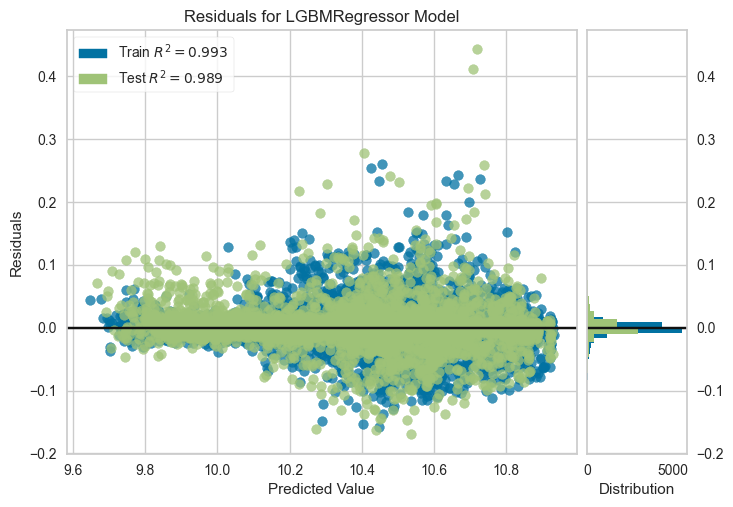

   -> Generating Prediction Error Plot...


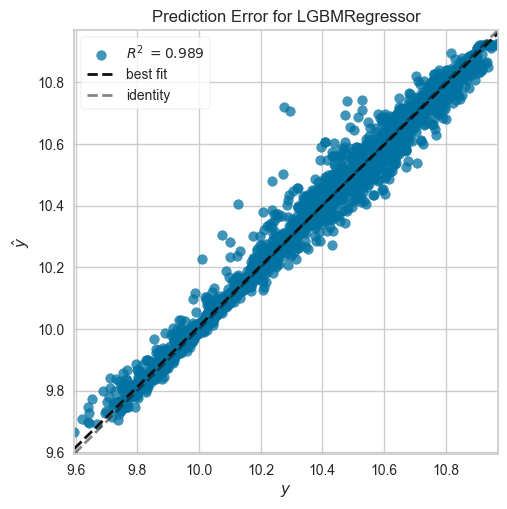

   -> Plots generated and displayed.


In [15]:

# =============================================================================
# NEW: STEP 7 - EVALUATE ON HOLD-OUT SET (RMSE, R2, etc.)
# =============================================================================
print("\n7. Evaluating Best Model on Hold-Out Set...")
# This runs prediction on the 30% hold-out set and prints the scoreboard (RMSE, R2, etc.)
hold_out_metrics = predict_model(best_model)
print(hold_out_metrics.head()) # Display the first few rows of predictions & metrics

# =============================================================================
# NEW: STEP 8 - PLOT RESIDUALS
# =============================================================================
print("\n8. Generating Diagnostic Plots (using Hold-Out Set)...")

# Plot 1: Residuals vs. Predicted
# This is the "random cloud" plot.
print("   -> Generating Residuals Plot...")
plot_model(best_model, plot='residuals') 
# Removed 'save=True' to display plot directly in the notebook

# Plot 2: Actual vs. Predicted (Error Plot)
# This shows how far predictions are from the perfect y=x line.
print("   -> Generating Prediction Error Plot...")
plot_model(best_model, plot='error')
# Removed 'save=True' to display plot directly in the notebook

print("   -> Plots generated and displayed.")
